In [ ]:
# %pip install pandas scikit-learn matplotlib seaborn jupyter numpy scipy

Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd

In [27]:
# Load dataset and remove missing values from relevant columns
df = pd.read_csv("./data/pricerunner_aggregate.csv")   
df = df.dropna()

df.head()

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [28]:
# Dataset Columns
df.columns

Index(['Product ID', 'Product Title', ' Merchant ID', ' Cluster ID',
       ' Cluster Label', ' Category ID', ' Category Label'],
      dtype='object')

In [29]:
# Clean Columns
df.columns = df.columns.str.strip()
df = df.dropna(subset=["Product Title", "Category Label"])
df.head()

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [30]:
# Train / Test Split
from sklearn.model_selection import train_test_split

X = df["Product Title"].astype(str)
y = df["Category Label"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 28248
Test set size: 7063


In [31]:
# TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_df=0.9,
    min_df=5
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)


In [32]:
# Train Classifier
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [33]:
# Evaluation of the models

from sklearn.metrics import classification_report, accuracy_score

y_pred = clf.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9545518901316721
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       773
 Digital Cameras       1.00      0.99      0.99       540
     Dishwashers       0.94      0.96      0.95       685
        Freezers       0.98      0.89      0.93       442
 Fridge Freezers       0.94      0.92      0.93      1100
         Fridges       0.88      0.90      0.89       717
      Microwaves       0.98      0.94      0.96       468
   Mobile Phones       0.97      0.99      0.98       816
             TVs       0.97      0.98      0.98       713
Washing Machines       0.93      0.96      0.94       809

        accuracy                           0.95      7063
       macro avg       0.96      0.95      0.96      7063
    weighted avg       0.96      0.95      0.95      7063



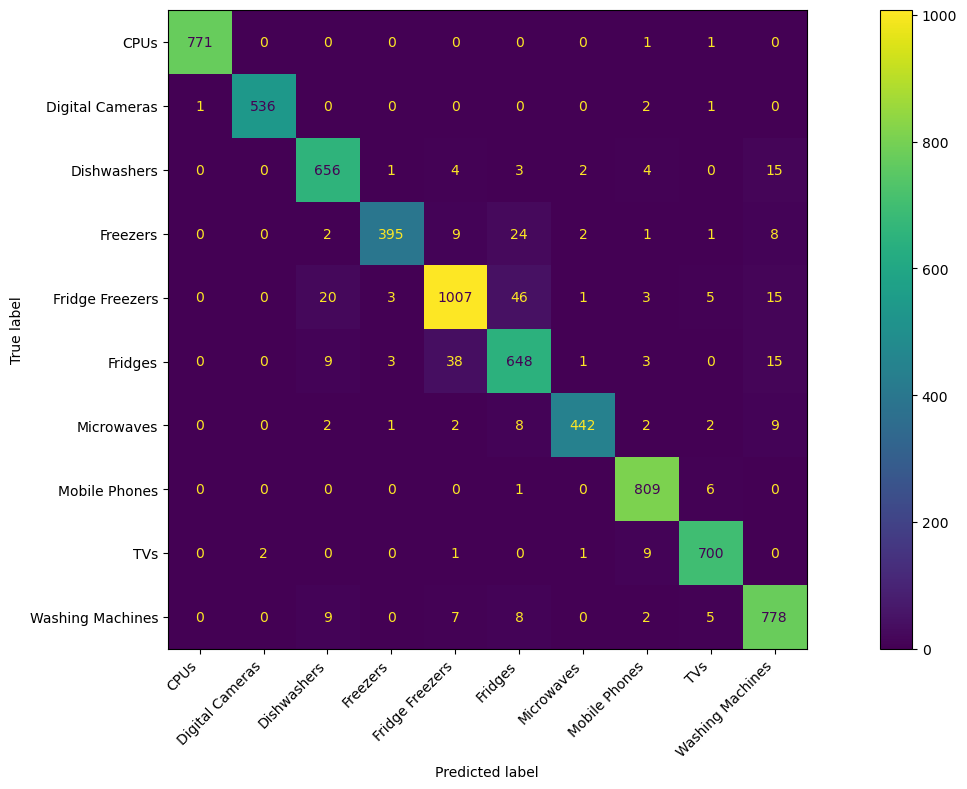

In [34]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.yticks(rotation=0)  # Keep y-axis labels horizontal
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

In [35]:
# Trying with another Model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_vec, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
# Evaluation of Naive-Bayes models

from sklearn.metrics import classification_report, accuracy_score

y_rf_pred = rf.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_rf_pred))
print(classification_report(y_test, y_rf_pred))

Accuracy: 0.9539855585445278
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       773
 Digital Cameras       1.00      0.99      0.99       540
     Dishwashers       0.92      0.96      0.94       685
        Freezers       0.94      0.91      0.93       442
 Fridge Freezers       0.95      0.91      0.93      1100
         Fridges       0.90      0.89      0.90       717
      Microwaves       0.98      0.95      0.97       468
   Mobile Phones       0.97      0.99      0.98       816
             TVs       0.97      0.99      0.98       713
Washing Machines       0.92      0.96      0.94       809

        accuracy                           0.95      7063
       macro avg       0.96      0.95      0.95      7063
    weighted avg       0.95      0.95      0.95      7063



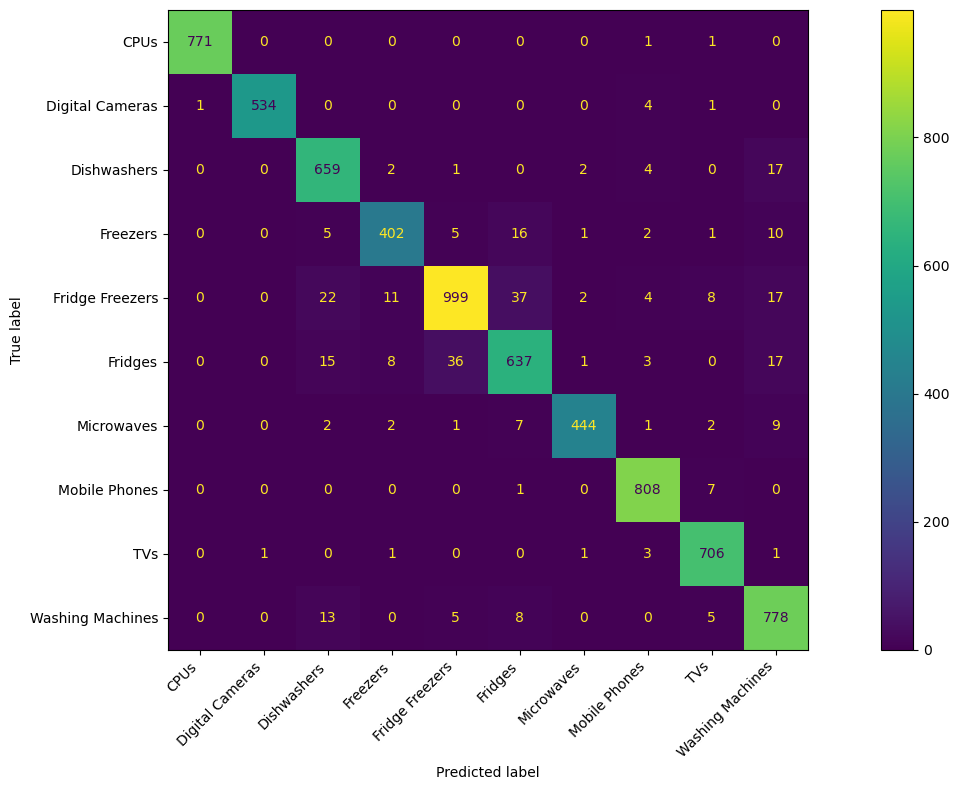

In [37]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_rf_pred, ax=ax)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.yticks(rotation=0)  # Keep y-axis labels horizontal
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()